# Chapter 11: Machine Learning Basics for MBA Data Analysts

**Goal**  
Learn the most useful machine-learning techniques that MBA professionals and business analysts actually use:  
- Predicting continuous outcomes (sales, revenue, demand)  
- Classifying customers / risk / churn  
- Finding natural groups (segmentation)  
- Evaluating models correctly  

We stay practical – every concept is tied to a business decision.

---

## 11.1 What is Machine Learning in a Business Context?

Machine Learning (ML) is the ability of a computer to learn patterns from data and make predictions or decisions **without being explicitly programmed** for every rule.

For an MBA data analyst the most common questions are:

| Business Question | ML Type | Example |
|-------------------|---------|---------|
| How much will we sell next month? | Regression | Sales forecasting |
| Will this customer churn? | Classification | Churn prediction |
| Which customers behave similarly? | Clustering | Customer segmentation |
| Which marketing channel works best? | Classification / Regression | Campaign ROI |

We will use **scikit-learn** – the industry-standard library for classical ML.


In [12]:
# Install / import the libraries we need
# (run once if not already installed)
# !pip install scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Libraries ready!")


Libraries ready!


---
## 11.2 Descriptive Statistics Recap (Mean, Median, Mode, Std Dev, Percentile)

Before modelling we always understand the data.


In [13]:
# Business example: Monthly sales of 5 products (in ₹ lakhs)
sales = np.array([12.5, 18.0, 9.5, 22.0, 15.5, 18.0, 14.0, 19.5, 16.0, 18.0])

print("Mean (average):", round(np.mean(sales), 2))
print("Median:", np.median(sales))
print("Mode (most frequent):", pd.Series(sales).mode().values)
print("Standard Deviation:", round(np.std(sales, ddof=1), 2))
print("25th Percentile (Q1):", np.percentile(sales, 25))
print("75th Percentile (Q3):", np.percentile(sales, 75))
print("IQR:", round(np.percentile(sales, 75) - np.percentile(sales, 25), 2))


Mean (average): 16.3
Median: 17.0
Mode (most frequent): [18.]
Standard Deviation: 3.62
25th Percentile (Q1): 14.375
75th Percentile (Q3): 18.0
IQR: 3.62


---
## 11.3 Linear Regression – Predicting Continuous Business Outcomes

**Business Case**: Predict monthly advertising spend → revenue relationship.


    Ad_Spend     Revenue
0  50.000000  192.417854
1  56.410256  194.492110
2  62.820513  232.089649
3  69.230769  271.921900
4  75.641026  245.941037


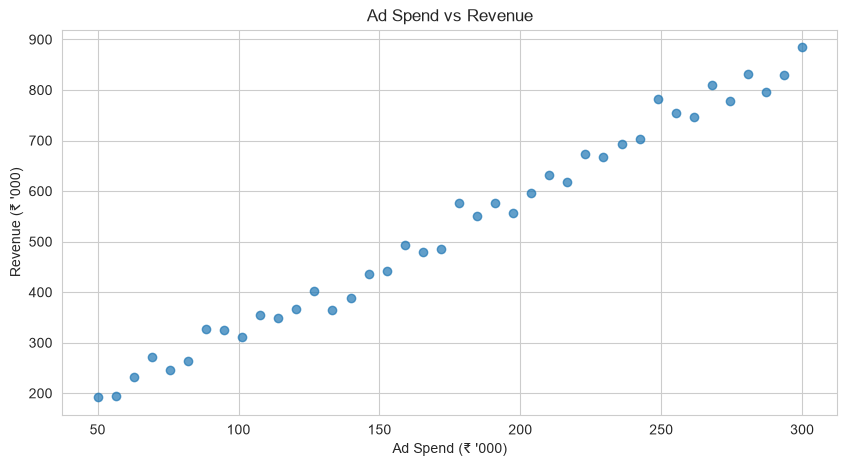

In [14]:
# Synthetic but realistic data
np.random.seed(42)
ad_spend = np.linspace(50, 300, 40)                          # ₹ '000
revenue = 2.8 * ad_spend + 40 + np.random.normal(0, 25, 40)  # ₹ '000

df = pd.DataFrame({"Ad_Spend": ad_spend, "Revenue": revenue})
print(df.head())

# Visualise
plt.scatter(df["Ad_Spend"], df["Revenue"], alpha=0.7)
plt.xlabel("Ad Spend (₹ '000)")
plt.ylabel("Revenue (₹ '000)")
plt.title("Ad Spend vs Revenue")
plt.show()


In [15]:
# Train Linear Regression
X = df[["Ad_Spend"]]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient (lift per ₹1k ad spend): {model.coef_[0]:.2f}")

# Predictions & evaluation
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Business interpretation
print("\n→ Every extra ₹1,000 spent on ads is associated with ≈ ₹{:.0f} extra revenue.".format(model.coef_[0]*1000))


Intercept: 46.40
Coefficient (lift per ₹1k ad spend): 2.74
R² Score: 0.985
RMSE: 23.90

→ Every extra ₹1,000 spent on ads is associated with ≈ ₹2740 extra revenue.


---
## 11.4 Multiple Linear Regression

Add more predictors: Ad Spend + Seasonality + Competitor Price.


In [16]:
np.random.seed(42)
n = 100
data = pd.DataFrame({
    "Ad_Spend": np.random.uniform(50, 300, n),
    "Seasonality": np.random.randint(1, 5, n),          # 1=Q1 ... 4=Q4
    "Comp_Price": np.random.uniform(80, 150, n)
})
data["Revenue"] = (2.5*data["Ad_Spend"] + 15*data["Seasonality"]
                   - 1.2*data["Comp_Price"] + 50
                   + np.random.normal(0, 20, n))

X = data[["Ad_Spend", "Seasonality", "Comp_Price"]]
y = data["Revenue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi = LinearRegression()
multi.fit(X_train, y_train)
print("Coefficients:")
for feat, coef in zip(X.columns, multi.coef_):
    print(f"  {feat}: {coef:.2f}")
print(f"R² on test: {r2_score(y_test, multi.predict(X_test)):.3f}")


Coefficients:
  Ad_Spend: 2.44
  Seasonality: 12.72
  Comp_Price: -1.24
R² on test: 0.993


---
## 11.5 Polynomial Regression (when relationships are curved)

Useful for diminishing returns (e.g., advertising saturation).


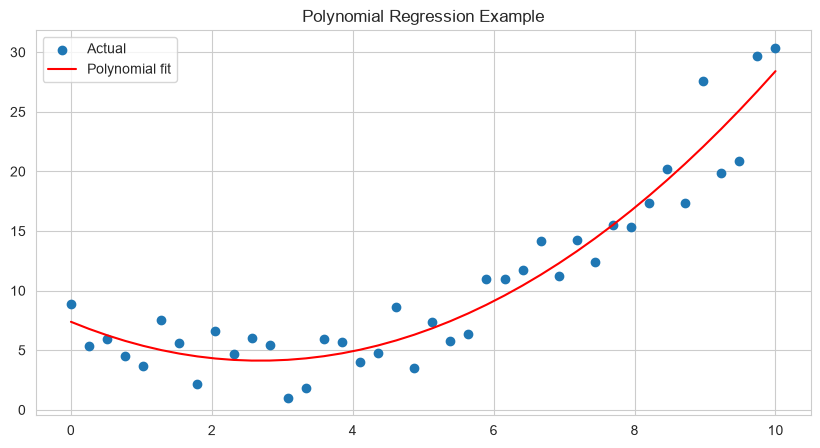

R²: 0.91716002035498


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Simple curved data
x = np.linspace(0, 10, 40).reshape(-1, 1)
y = 0.5*x.ravel()**2 - 3*x.ravel() + 8 + np.random.normal(0, 3, 40)

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(x, y)

# Plot
plt.scatter(x, y, label="Actual")
plt.plot(x, poly_model.predict(x), color="red", label="Polynomial fit")
plt.legend()
plt.title("Polynomial Regression Example")
plt.show()
print("R²:", r2_score(y, poly_model.predict(x)))


---
## 11.6 Train / Test Split & Why It Matters

Never evaluate a model on the same data it was trained on – that leads to over-optimistic results (overfitting).


In [18]:
# Already demonstrated above. Key rule for MBA analysts:
# Always keep 20-30% of data as an untouched "hold-out" test set.
print("Best practice: train_test_split(..., test_size=0.2 or 0.25)")


Best practice: train_test_split(..., test_size=0.2 or 0.25)


---
## 11.7 Logistic Regression – Classification (Churn / Yes-No decisions)

**Business Case**: Predict whether a customer will churn (1) or stay (0).


In [19]:
np.random.seed(42)
n = 200
churn_df = pd.DataFrame({
    "Tenure_months": np.random.randint(1, 60, n),
    "Monthly_Charges": np.random.uniform(30, 120, n),
    "Support_Tickets": np.random.randint(0, 8, n)
})
# Higher charges + more tickets + low tenure → higher churn probability
logit = -3 + 0.04*churn_df["Monthly_Charges"] + 0.35*churn_df["Support_Tickets"] - 0.06*churn_df["Tenure_months"]
prob = 1 / (1 + np.exp(-logit))
churn_df["Churn"] = (np.random.rand(n) < prob).astype(int)

print(churn_df["Churn"].value_counts())
print(churn_df.head())


Churn
0    122
1     78
Name: count, dtype: int64
   Tenure_months  Monthly_Charges  Support_Tickets  Churn
0             39        39.494483                6      1
1             52        71.088111                0      0
2             29        49.659639                3      0
3             15        67.485895                4      0
4             43       109.495223                0      1


In [20]:
X = churn_df[["Tenure_months", "Monthly_Charges", "Support_Tickets"]]
y = churn_df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))


Accuracy: 0.88

Confusion Matrix:
[[29  2]
 [ 4 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        31
           1       0.88      0.79      0.83        19

    accuracy                           0.88        50
   macro avg       0.88      0.86      0.87        50
weighted avg       0.88      0.88      0.88        50

ROC-AUC: 0.883


---
## 11.8 Decision Tree (easy to explain to management)


In [21]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree.predict(X_test)))

# Feature importance – very useful for MBA storytelling
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:")
print(imp)


Decision Tree Accuracy: 0.7

Feature Importance:
Monthly_Charges    0.481317
Tenure_months      0.456252
Support_Tickets    0.062430
dtype: float64


---
## 11.9 K-Means Clustering – Customer Segmentation


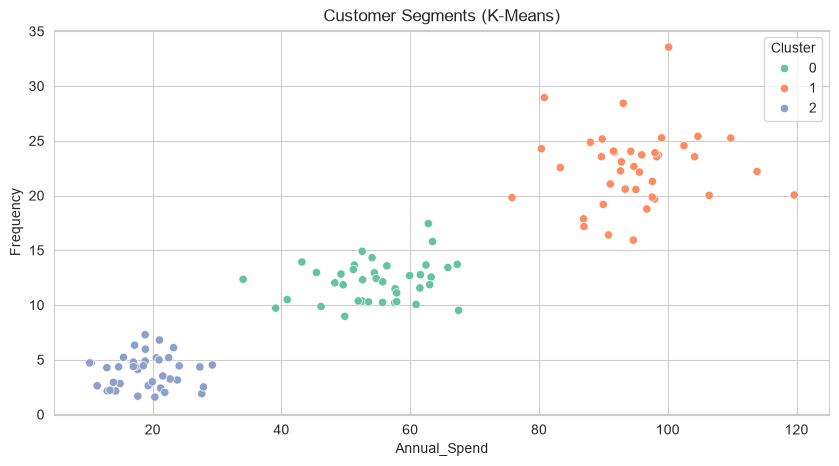

         Annual_Spend  Frequency
Cluster                         
0                54.8       12.1
1                95.1       22.6
2                18.9        4.0


In [22]:
# Customer data: Annual Spend & Frequency of purchase
np.random.seed(42)
seg = pd.DataFrame({
    "Annual_Spend": np.concatenate([
        np.random.normal(20, 5, 40),   # low
        np.random.normal(55, 8, 40),   # mid
        np.random.normal(95, 10, 40)   # high
    ]),
    "Frequency": np.concatenate([
        np.random.normal(4, 1.5, 40),
        np.random.normal(12, 2, 40),
        np.random.normal(22, 3, 40)
    ])
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
seg["Cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=seg, x="Annual_Spend", y="Frequency", hue="Cluster", palette="Set2")
plt.title("Customer Segments (K-Means)")
plt.show()

print(seg.groupby("Cluster")[["Annual_Spend", "Frequency"]].mean().round(1))


---
## 11.10 Hierarchical Clustering (when you want a dendrogram)


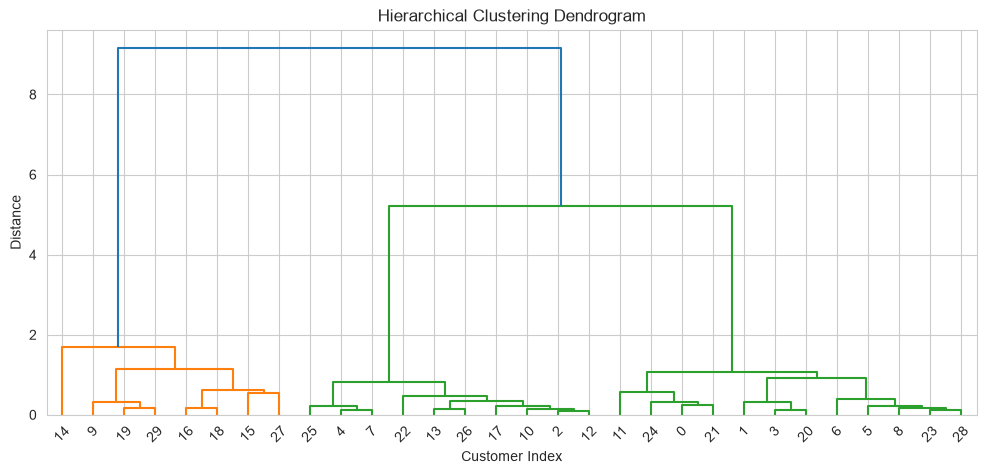

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a smaller sample for clear dendrogram
sample = seg.sample(30, random_state=42)
Z = linkage(scaler.fit_transform(sample[["Annual_Spend", "Frequency"]]), method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()


---
## 11.11 K-Nearest Neighbors (KNN)


In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))


KNN Accuracy: 0.68


---
## 11.12 Model Evaluation Essentials for Business

- **Confusion Matrix** – True Positives, False Positives, etc.  
- **ROC-AUC** – overall ranking ability (especially useful when classes are imbalanced)  
- **Cross-Validation** – more reliable performance estimate  
- **Grid Search** – systematic hyper-parameter tuning


In [25]:
# Cross-validation example
cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring="roc_auc")
print("5-Fold CV ROC-AUC:", cv_scores.round(3), "→ Mean:", round(cv_scores.mean(), 3))

# Simple Grid Search on Decision Tree
param_grid = {"max_depth": [2, 3, 4, 5], "min_samples_leaf": [5, 10, 20]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 3))


5-Fold CV ROC-AUC: [0.768 0.872 0.753 0.848 0.944] → Mean: 0.837
Best params: {'max_depth': 3, 'min_samples_leaf': 20}
Best CV accuracy: 0.773


---
## 11.13 Business Challenge – Chapter 11

**Scenario**  
You work for a retail bank. Management wants a simple model that predicts which existing customers are likely to take a personal loan (binary classification).

**Data** (you can create synthetic or use any open dataset):  
- Age, Income, Family size, Education, CCAvg (credit card spending), Mortgage, etc.

**Tasks**
1. Build a Logistic Regression and a Decision Tree.
2. Compare Accuracy, Confusion Matrix and ROC-AUC.
3. Identify the top 2-3 drivers of loan acceptance.
4. Write a 5-bullet executive summary that a non-technical manager can understand.

**Bonus**  
Try K-Means on the same data to find natural customer segments and see whether loan uptake differs by segment.


---
### Key Takeaways for MBA Data Analysts
- Always start with a clear business question.
- Split data properly (Train / Test).
- Prefer interpretable models (Linear / Logistic / shallow Trees) when talking to management.
- Evaluate with metrics that matter to the business (cost of false positives vs false negatives).
- Clustering is unsupervised – great for segmentation and discovery.
